Hier muss noch einleitend etwas hin.

In [47]:
import pickle
import pandas as pd
df = pd.read_pickle('../../data/processed/25_cleaned_master_data.pkl')

In [48]:
print(df.info())
print(df.select_dtypes(include='object').nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196048 entries, 0 to 196047
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   meta_race                    196048 non-null  category      
 1   meta_year                    196048 non-null  int64         
 2   meta_url                     196048 non-null  object        
 3   rank                         196048 non-null  float64       
 4   meta_rider_url               196048 non-null  object        
 5   height                       196048 non-null  float64       
 6   meta_name                    196048 non-null  object        
 7   meta_nationality             196048 non-null  category      
 8   weight                       196048 non-null  int64         
 9   meta_url_name                196048 non-null  object        
 10  meta_departure               196048 non-null  object        
 11  meta_arrival              

## metrische Spalten (Intervall- und Verhältnisskaliert)
### Begründung: Spearman statt Pearson

Für die Korrelationsanalyse der metrischen Spalten wurde der **Spearman-Korrelationskoeffizient** anstelle von Pearson gewählt. Ausschlaggebend dafür waren drei Eigenschaften des Datensatzes:

**Zielvariable `rank` ist eine Rangvariable.** `rank` beschreibt die Platzierung eines Fahrers und ist damit ordinalskaliert. Pearson setzt echtes Intervallniveau voraus, bei dem gleiche Abstände zwischen Werten bedeutsam sind – das ist bei Platzierungen nicht gegeben.

**Schiefe Verteilungen.** Spalten wie `rider_points_season`, `sprint` oder `team_power_index` sind rechtsschief, da die meisten Fahrer niedrige Werte aufweisen und nur wenige Ausnahmen sehr hohe. Pearson reagiert empfindlich auf solche Verteilungen, da er einen linearen Zusammenhang und annähernde Normalverteilung voraussetzt. Spearman arbeitet hingegen mit Rängen der Rohwerte und ist damit verteilungsunabhängig.

**Robustheit gegenüber Ausreißern.**

In [49]:
from scipy.stats import spearmanr
import pandas as pd

metric_cols = ['height', 'weight', 'rider_bmi', 'age_at_race',
               'distance', 'vertical_meters', 'gradient_final_km',
               'sprint', 'climber', 'gc', 'time_trial', 'hills', 'one_day_races',
               'rider_points_season', 'team_power_index',
               'race_competitiveness_median', 'weather_temp_mean',
               'weather_rain_prob_mean', 'wind_stability_index',
               'weather_humidity_mean', 'weather_precipitation_mean']

# Spearman-Korrelation jeder Spalte mit rank
results = []
for col in metric_cols:
    rho, p = spearmanr(df['rank'], df[col])
    results.append({'Feature': col, 'Spearman ρ': round(rho, 3), 'p-Wert': round(p, 4)})

corr_with_rank = pd.DataFrame(results).sort_values(by = 'Spearman ρ', ascending=False)
print(corr_with_rank)

                        Feature  Spearman ρ  p-Wert
1                        weight       0.201  0.0000
2                     rider_bmi       0.163  0.0000
0                        height       0.120  0.0000
14             team_power_index       0.112  0.0000
4                      distance       0.026  0.0000
15  race_competitiveness_median       0.020  0.0000
16            weather_temp_mean       0.019  0.0000
7                        sprint       0.016  0.0000
18         wind_stability_index      -0.005  0.0260
6             gradient_final_km      -0.008  0.0008
19        weather_humidity_mean      -0.012  0.0000
20   weather_precipitation_mean      -0.019  0.0000
17       weather_rain_prob_mean      -0.020  0.0000
3                   age_at_race      -0.031  0.0000
5               vertical_meters      -0.033  0.0000
12                one_day_races      -0.141  0.0000
10                   time_trial      -0.150  0.0000
11                        hills      -0.272  0.0000
13          

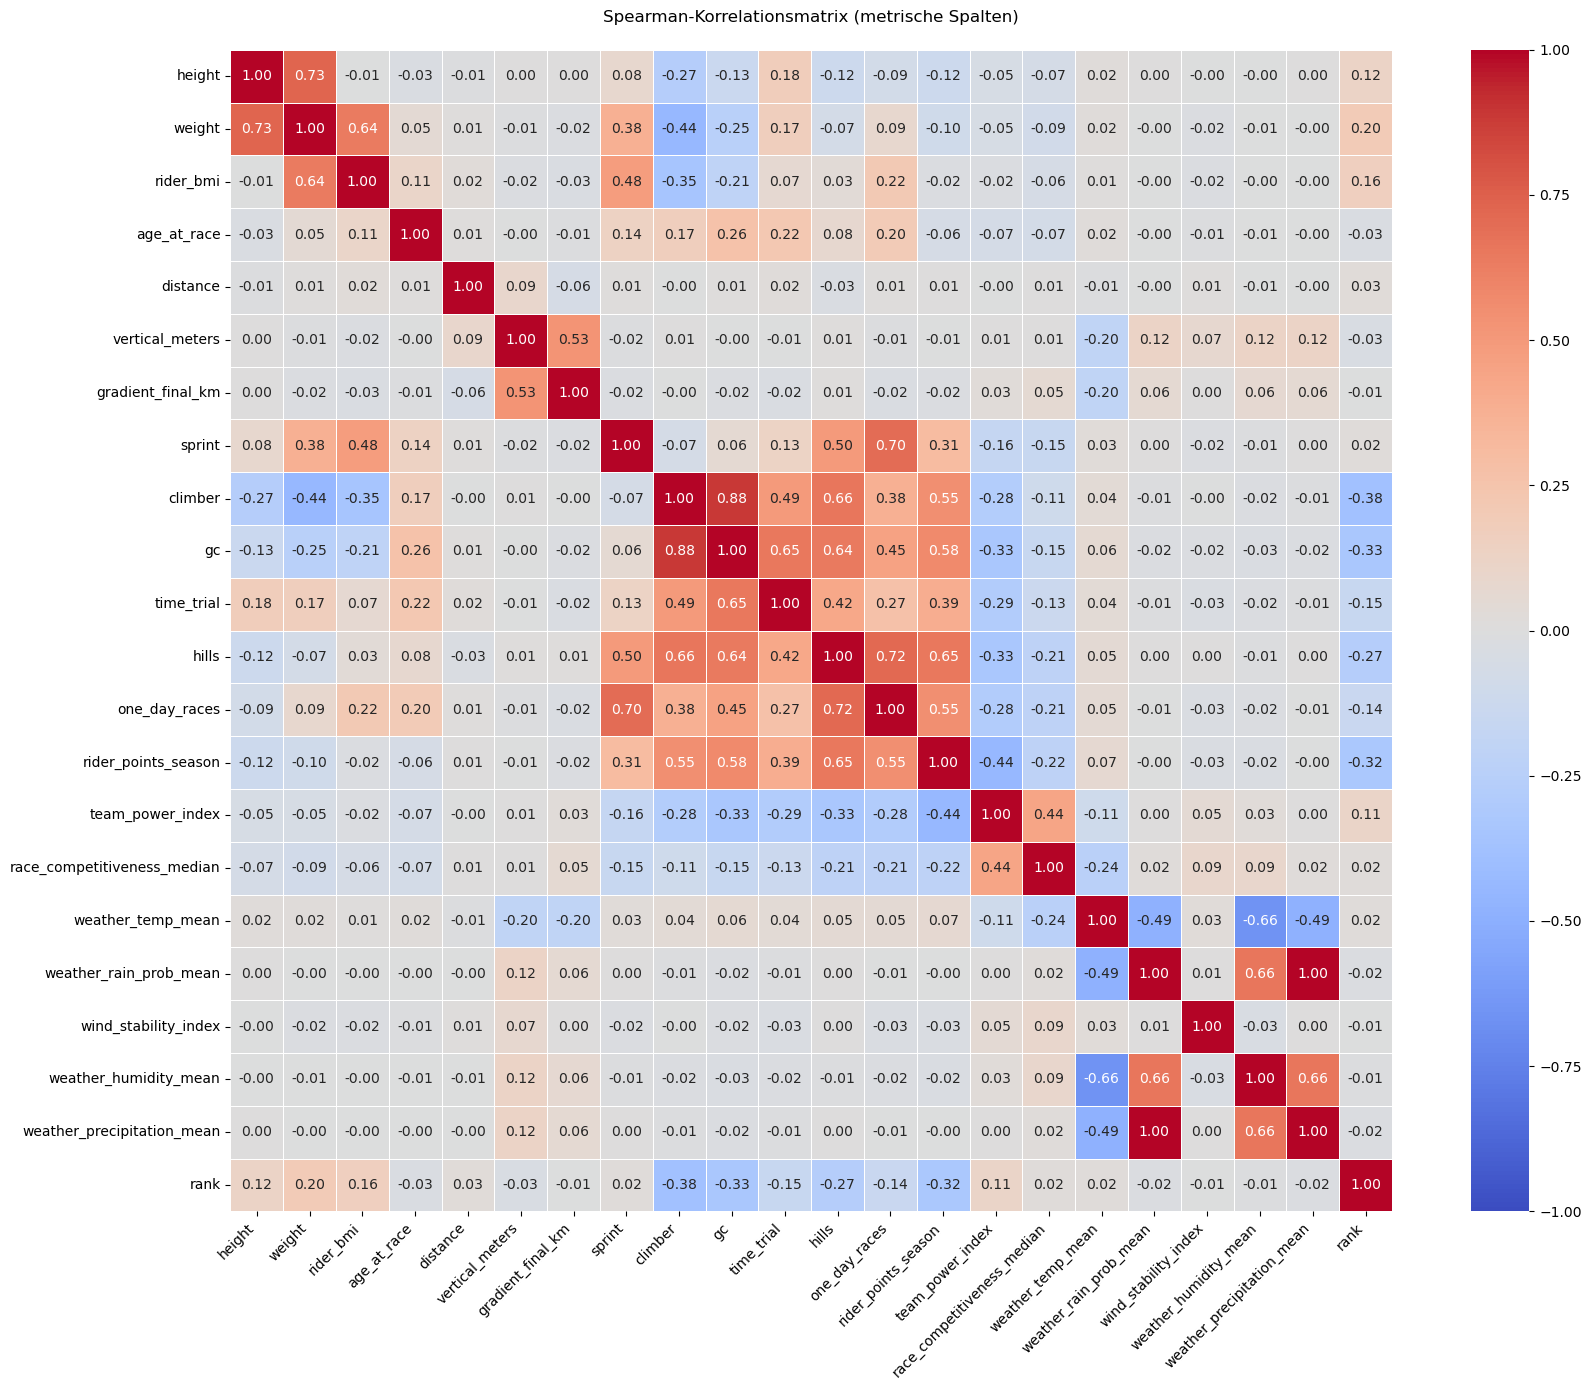

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

metric_cols = ['height', 'weight', 'rider_bmi', 'age_at_race',
               'distance', 'vertical_meters', 'gradient_final_km',
               'sprint', 'climber', 'gc', 'time_trial', 'hills', 'one_day_races',
               'rider_points_season', 'team_power_index',     
               'race_competitiveness_median', 'weather_temp_mean',
               'weather_rain_prob_mean', 'wind_stability_index',
               'weather_humidity_mean', 'weather_precipitation_mean',
               'rank']  # rank am Ende – so siehst du die letzte Zeile/Spalte als Zielvariable

corr = df[metric_cols].corr(method='spearman')

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    annot=True,          # Zahlenwerte anzeigen
    fmt=".2f",           # 2 Dezimalstellen
    cmap='coolwarm',     # Rot = positiv, Blau = negativ
    center=0,            # 0 = weiß/neutral
    vmin=-1, vmax=1,
    linewidths=0.5,      # Gitterlinien zwischen Zellen
    square=True          # Quadratische Zellen
)
plt.title("Spearman-Korrelationsmatrix (metrische Spalten)", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Übersichtlichere Abbildung: Korrelation der metrischen Variablen mit der Zielvariable `rank`.

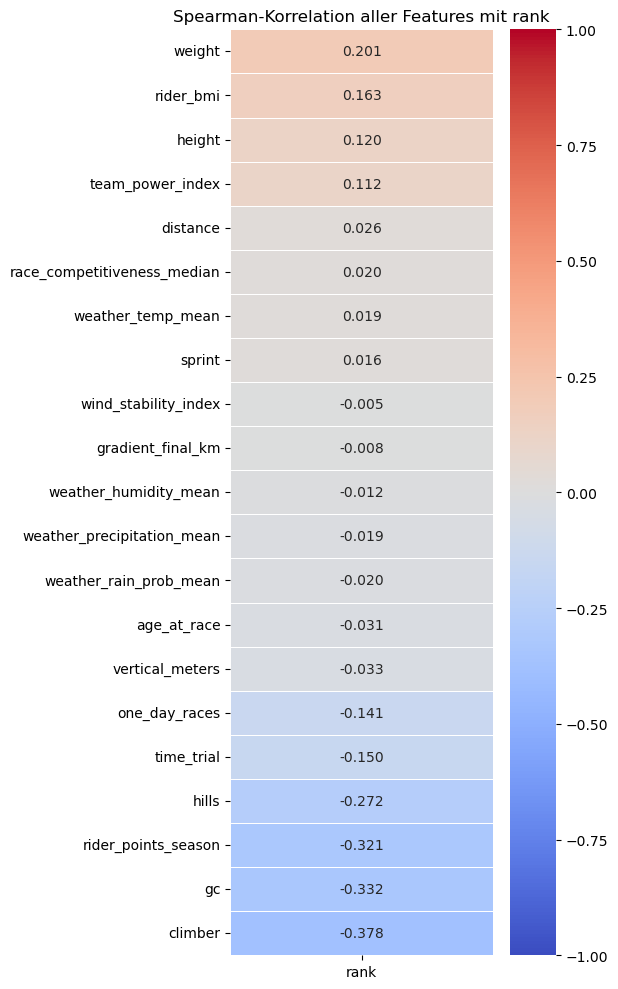

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

metric_cols = ['height', 'weight', 'rider_bmi', 'age_at_race',
               'distance', 'vertical_meters', 'gradient_final_km',
               'sprint', 'climber', 'gc', 'time_trial', 'hills', 'one_day_races',
               'rider_points_season', 'team_power_index',     
               'race_competitiveness_median', 'weather_temp_mean',
               'weather_rain_prob_mean', 'wind_stability_index',
               'weather_humidity_mean', 'weather_precipitation_mean',
               'rank'] 

rank_corr = corr[['rank']].drop('rank').sort_values(by = 'rank', ascending = False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    rank_corr,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Spearman-Korrelation aller Features mit rank")
plt.tight_layout()
plt.show()

### Ordinale Spalten

In [52]:
from scipy.stats import spearmanr

ordinal_cols = ['rider_rank_season', 'stage_nr']

results = []
for col in ordinal_cols:
    rho, p = spearmanr(df['rank'], df[col])
    results.append({'Feature': col, 'Spearman ρ': round(rho, 3), 'p-Wert': round(p, 4)})

corr_with_rank = pd.DataFrame(results).sort_values('Spearman ρ', key=abs, ascending=False)
print(corr_with_rank)

             Feature  Spearman ρ  p-Wert
0  rider_rank_season       0.325     0.0
1           stage_nr      -0.111     0.0


## Kategoriale Spalten (Nominalskaliert)
### Begründung: Kruskal-Wallis-Test

Für den Vergleich von `rank` über kategoriale Gruppen (`team_tier`, `meta_race`, `won_how_cat`) wurde der **Kruskal-Wallis-Test** gewählt, da `rank` als Rangvariable nicht normalverteilt ist und damit die Voraussetzungen einer ANOVA nicht erfüllt. Als nicht-parametrisches Äquivalent verzichtet der Kruskal-Wallis-Test auf Verteilungsannahmen und ist zudem robust gegenüber Ausreißern.

rank × team_tier: Kruskal-Wallis H = 817.71, p = 0.0000


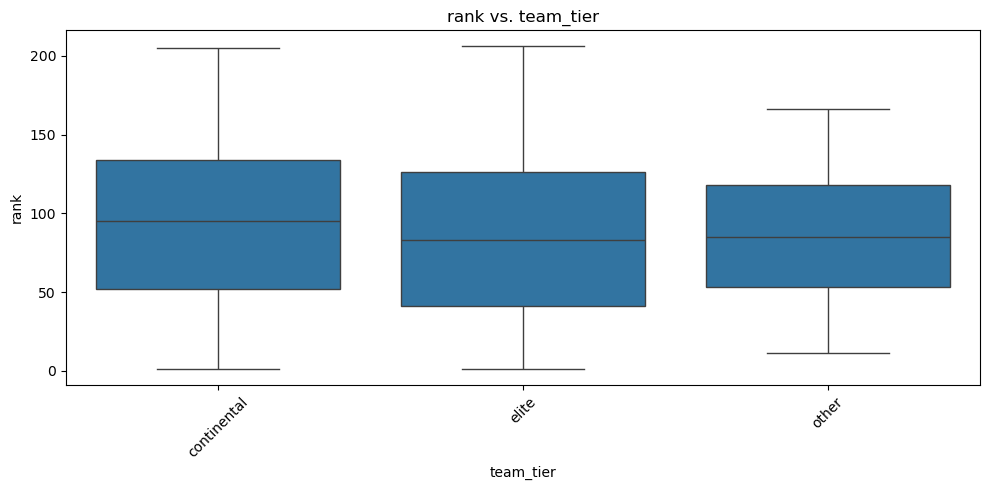

rank × meta_race: Kruskal-Wallis H = 16.57, p = 0.0003


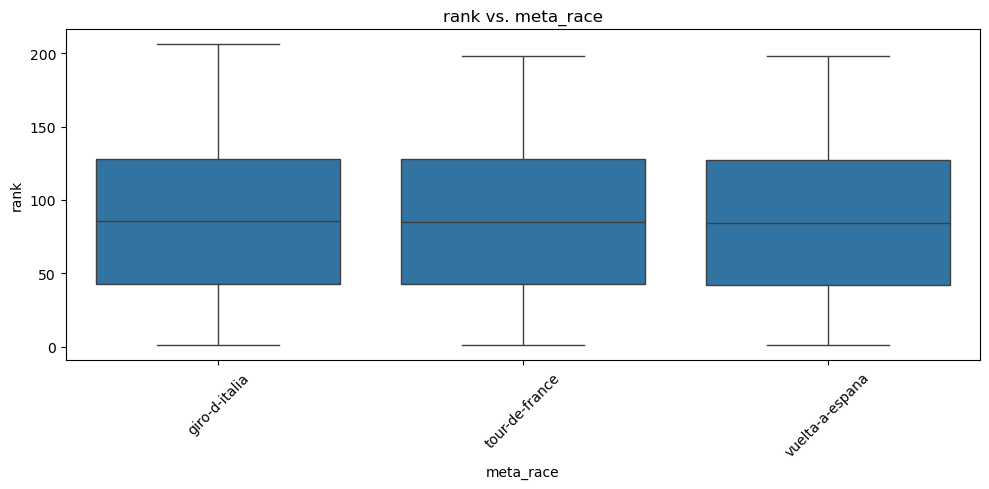

rank × won_how_cat: Kruskal-Wallis H = 303.50, p = 0.0000


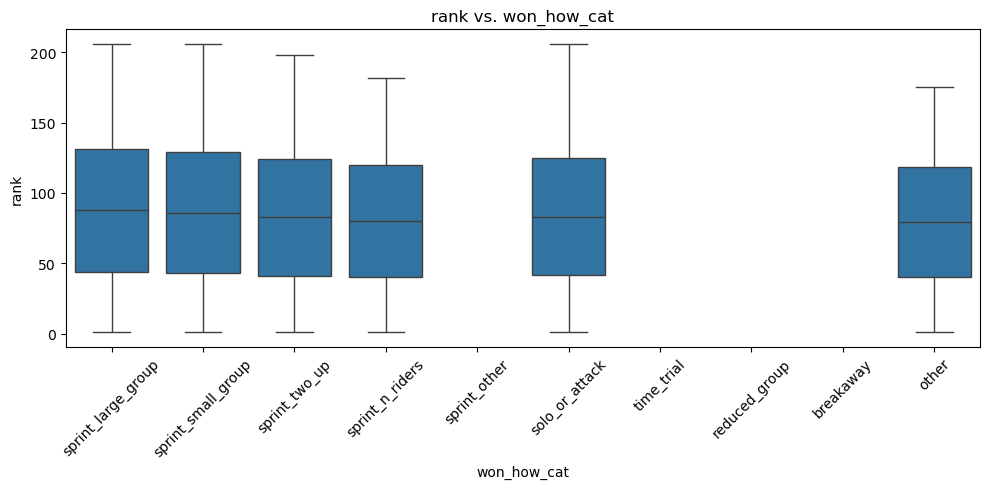

In [53]:
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

for cat_col in ['team_tier', 'meta_race', 'won_how_cat']:
    groups = [group['rank'].values for _, group in df.groupby(cat_col, observed=True)]
    stat, p = kruskal(*groups)
    print(f"rank × {cat_col}: Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")

    # Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=cat_col, y='rank')
    plt.title(f"rank vs. {cat_col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [56]:
print(df['won_how_cat'].value_counts())


won_how_cat
solo_or_attack        77264
sprint_large_group    67538
sprint_small_group    27233
sprint_two_up         19934
sprint_n_riders        3305
other                   774
Name: count, dtype: int64


rank × team_tier: Kruskal-Wallis H = 817.71, p = 0.0000


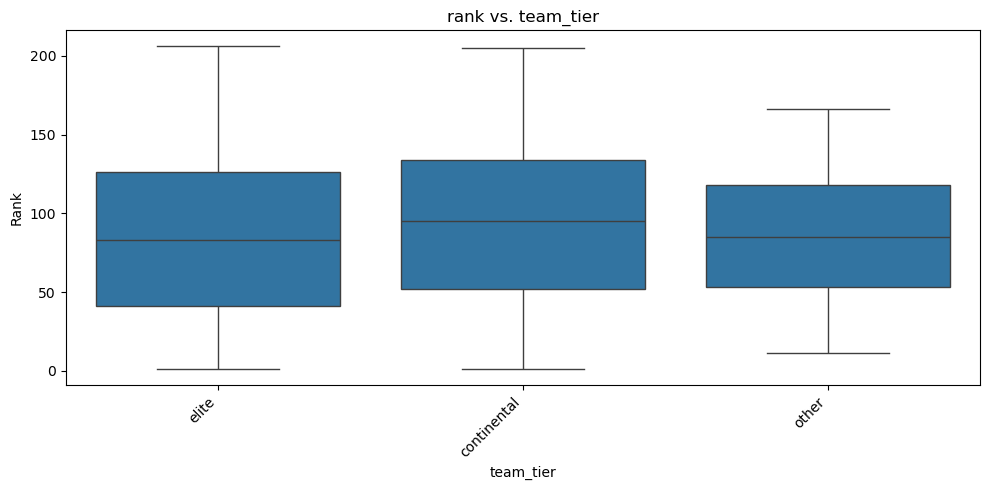

rank × meta_race: Kruskal-Wallis H = 16.57, p = 0.0003


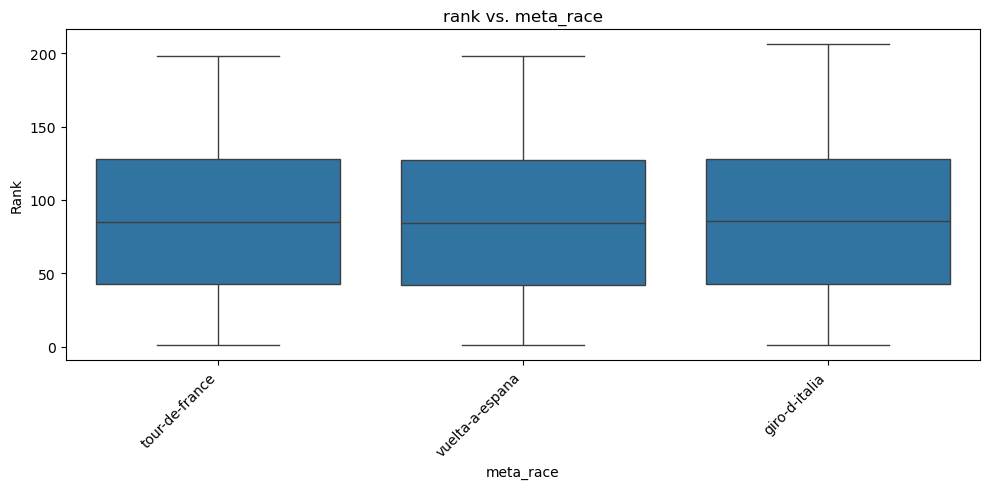

rank × won_how_cat: Kruskal-Wallis H = 303.50, p = 0.0000


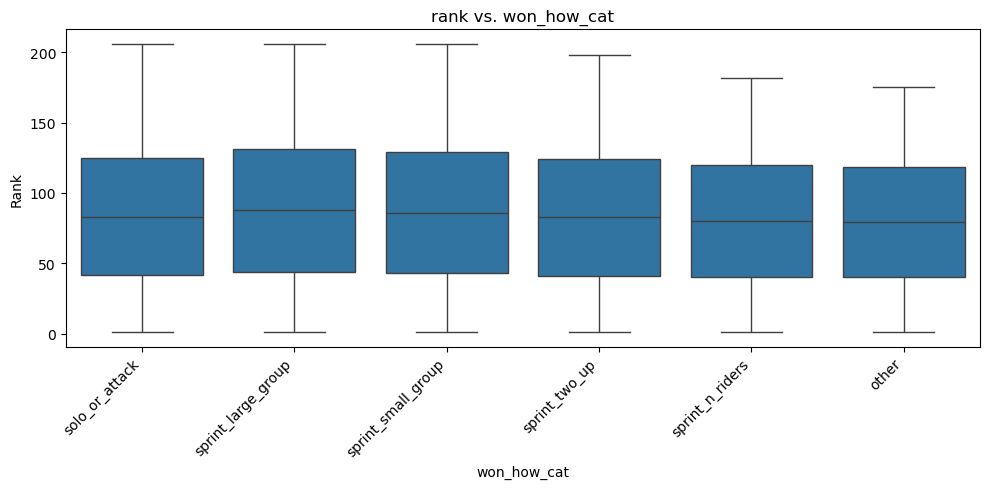

In [57]:
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

df['won_how_cat'] = df['won_how_cat'].cat.remove_unused_categories()

for cat_col in ['team_tier', 'meta_race', 'won_how_cat']:
    valid_cats = df[cat_col].value_counts()
    valid_cats = valid_cats[valid_cats >= 5].index
    df_filtered = df[df[cat_col].isin(valid_cats)]

    groups = [group['rank'].values 
              for _, group in df_filtered.groupby(cat_col, observed=True)]
    stat, p = kruskal(*groups)
    print(f"rank × {cat_col}: Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")

    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_filtered,
        x=cat_col,
        y='rank',
        order=df_filtered[cat_col].value_counts().index
    )
    plt.title(f"rank vs. {cat_col}")
    plt.xlabel(cat_col)
    plt.ylabel("Rank")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()
